# Analítica de Dados Empresariais
# Mestrado em Ciência de Dados para Empresas
## Machine Learning – Previsão de Churn de Clientes
Fluxo do trabalho:

Dados → Exploração → Preparação → Modelo → Avaliação → Risco → Ação de negócio


## 1. Importação das bibliotecas

In [1]:
# Ignorar avisos menos relevantes
import warnings
warnings.filterwarnings("ignore")

# Bibliotecas principais de análise
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Avaliação
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# Mostrar pipelines em diagrama
from sklearn import set_config
set_config(display="diagram")


## 2. Carregar o dataset

In [2]:
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='Credit_Risk_Dataset')
df.head()


# df = pd.read_csv("ADE_Sessao_ML_Dataset_Churn.csv") = codigo antigo

print("Dataset carregado com sucesso")
print("Dimensão:", df.shape)

print("\nPrimeiras linhas:")
print(df.head().to_string(index=False))


Saving Credit_Risk_Dataset.xlsx to Credit_Risk_Dataset.xlsx
Dataset carregado com sucesso
Dimensão: (500, 11)

Primeiras linhas:
ClientID  Age  Income  LoanAmount  LoanTerm  CreditScore  LatePayments  DebtToIncome EmploymentType Region  Outcome
 C100000   59    4774        1268        36          324             4          0.57      Part-time  North        0
 C100001   49    4067        5990        12          416             2          0.60      Part-time  North        1
 C100002   35    1625       16034        12          781             8          0.16      Full-time  South        0
 C100003   63    2316        7145        12          691             4          0.65      Full-time  South        0
 C100004   28    3946        5732        24          836             4          0.29      Full-time  South        1


## 3. Compreender os dados

In [9]:
print("Número de clientes:", len(df))

# garantir que a coluna é numérica
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

age = df["Age"].mean()

print("Age:", round(age,0))
# print("Age:", round(age*100,1), "%")

print("\nInformação estrutural:")
df.info()

print("\nTipos de dados:")
print(df.dtypes)

Número de clientes: 500
Age: 43.0

Informação estrutural:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ClientID        500 non-null    object 
 1   Age             500 non-null    int64  
 2   Income          500 non-null    int64  
 3   LoanAmount      500 non-null    int64  
 4   LoanTerm        500 non-null    int64  
 5   CreditScore     500 non-null    int64  
 6   LatePayments    500 non-null    int64  
 7   DebtToIncome    500 non-null    float64
 8   EmploymentType  500 non-null    object 
 9   Region          500 non-null    object 
 10  Outcome         500 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 43.1+ KB

Tipos de dados:
ClientID           object
Age                 int64
Income              int64
LoanAmount          int64
LoanTerm            int64
CreditScore         int64
LatePayments    

## 4. Exploração visual

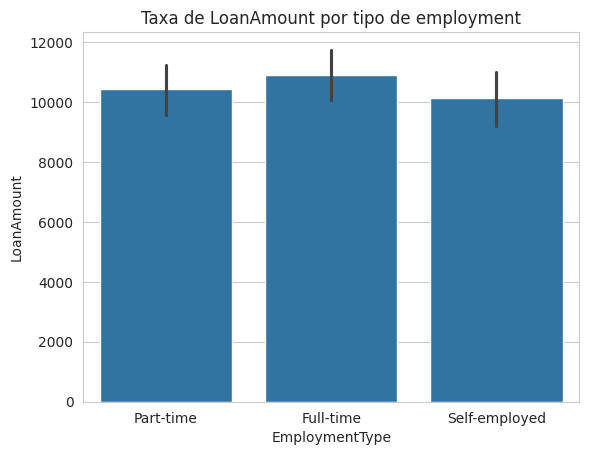

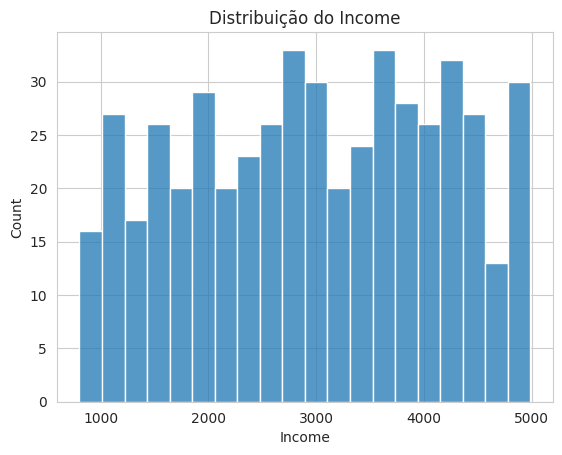

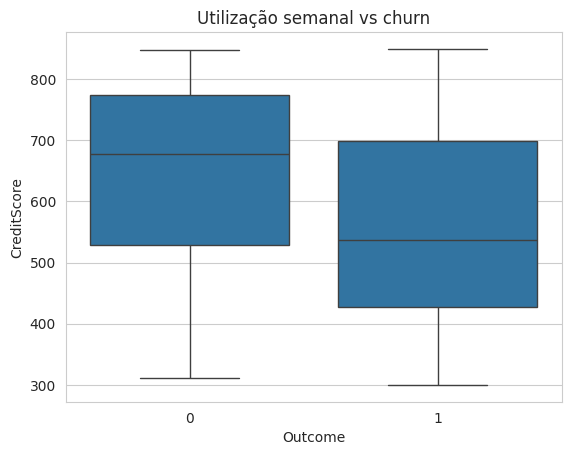

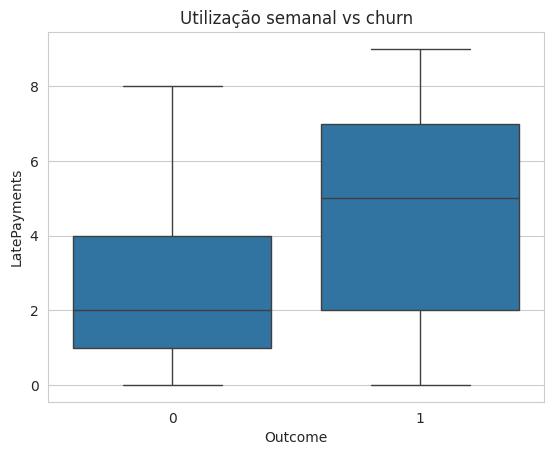

-0.07015947148495347


In [24]:
# Age  Income  LoanAmount  LoanTerm  CreditScore  LatePayments  DebtToIncome EmploymentType Region  Outcome

sns.barplot(data=df,x="EmploymentType",y="LoanAmount")
plt.title("Taxa de LoanAmount por tipo de employment")
plt.show()

sns.histplot(df["Income"],bins=20)
plt.title("Distribuição do Income")
plt.show()



sns.boxplot(data=df,x="Outcome",y="CreditScore")
plt.title("Utilização semanal vs churn")
plt.show()

sns.boxplot(data=df,x="Outcome",y="LatePayments")
plt.title("Utilização semanal vs churn")
plt.show()

corr = df['CreditScore'].corr(df['LatePayments'])
print(corr)


## 5. Definição das variáveis

In [25]:
# Age  Income  LoanAmount  LoanTerm  CreditScore  LatePayments  DebtToIncome EmploymentType Region  Outcome


target="Outcome"

features=[
"Age",
"Income",
"LoanAmount",
"LoanTerm",
"CreditScore",
"LatePayments",
"DebtToIncome",
"EmploymentType",
"Region"
]

X=df[features]
y=df[target]

print("Variável alvo:",target)
print("\nVariáveis explicativas:")

for f in features:
    print("-",f)


Variável alvo: Outcome

Variáveis explicativas:
- Age
- Income
- LoanAmount
- LoanTerm
- CreditScore
- LatePayments
- DebtToIncome
- EmploymentType
- Region


## 6. Tipos de variáveis

In [26]:
# Age  Income  LoanAmount  LoanTerm  CreditScore  LatePayments  DebtToIncome EmploymentType Region  Outcome

num=[
"Age",
"Income",
"LoanAmount",
"LoanTerm",
"CreditScore",
"LatePayments",
"DebtToIncome"
]

cat=[
"EmploymentType",
"Region"
]

print("Numéricas:",num)
print("Categóricas:",cat)


Numéricas: ['Age', 'Income', 'LoanAmount', 'LoanTerm', 'CreditScore', 'LatePayments', 'DebtToIncome']
Categóricas: ['EmploymentType', 'Region']


## 7. Divisão treino/teste

In [27]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.25,
random_state=42,
stratify=y
)

print("Treino:",X_train.shape)
print("Teste:",X_test.shape)


Treino: (375, 9)
Teste: (125, 9)


## 8. Pipeline de preparação dos dados

In [28]:
num_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
    ])
cat_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ])
prep=ColumnTransformer([
    ("num",num_pipe,num),
    ("cat",cat_pipe,cat)
    ])
print("Pipeline de preparação criado com sucesso")

display(prep)


Pipeline de preparação criado com sucesso


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Income', 'LoanAmount', 'LoanTerm',
                                  'CreditScore', 'LatePayments',
                                  'DebtToIncome']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['EmploymentType', 'Region'])])

## 9. Construção do modelo

In [29]:
model=Pipeline([
("prep",prep),
("clf",LogisticRegression(max_iter=1000,class_weight="balanced"))
])

model.fit(X_train,y_train)

print("Modelo treinado com sucesso")

display(model)


Modelo treinado com sucesso


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Income',
                                                   'LoanAmount', 'LoanTerm',
                                                   'CreditScore',
                                                   'LatePayments',
                                                   'DebtToIncome']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentType',
                                                   'Region'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## 10. Avaliação do modelo

              precision    recall  f1-score   support

           0       0.36      0.81      0.49        26
           1       0.92      0.62      0.74        99

    accuracy                           0.66       125
   macro avg       0.64      0.71      0.62       125
weighted avg       0.81      0.66      0.69       125

ROC AUC: 0.8146853146853147


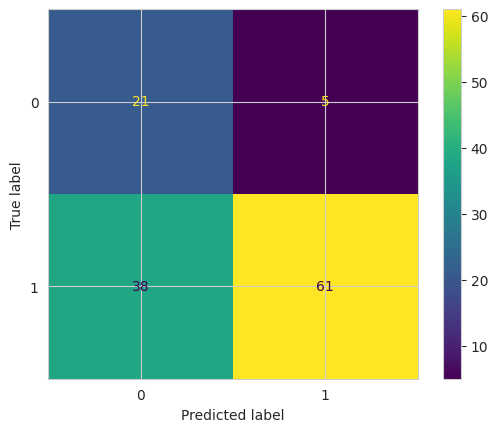

In [30]:
pred=model.predict(X_test)
proba=model.predict_proba(X_test)[:,1]

print(classification_report(y_test,pred))

print("ROC AUC:",roc_auc_score(y_test,proba))

ConfusionMatrixDisplay.from_predictions(y_test,pred)
plt.show()



## 11. Cálculo do risco de churn

In [34]:
# Age  Income  LoanAmount  LoanTerm  CreditScore  LatePayments  DebtToIncome EmploymentType Region  Outcome

df_scored=df.copy()

df_scored["Outcome"]=model.predict_proba(X)[:,1]

print("Maior risco:",df_scored["Outcome"].max())

print(df_scored[["ClientID","Outcome"]].head().to_string(index=False))


Maior risco: 0.9741288812208861
ClientID  Outcome
 C100000 0.693632
 C100001 0.630896
 C100002 0.697682
 C100003 0.553816
 C100004 0.356352


## 12. Estratégia de retenção

In [36]:
def action(r):

    if r >= 0.70:
        return "Recusar crédito"

    if r >= 0.50:
        return "Aprovar com condições (juros altos / fiador)"

    if r >= 0.30:
        return "Aprovar com monitorização"

    return "Aprovar normalmente"

df_scored["Recomendacao"]=df_scored["Outcome"].apply(action)

print(df_scored["Recomendacao"].value_counts())


Recomendacao
Recusar crédito                                 159
Aprovar com condições (juros altos / fiador)    130
Aprovar com monitorização                       125
Aprovar normalmente                              86
Name: count, dtype: int64


## 13. Distribuição das estratégias

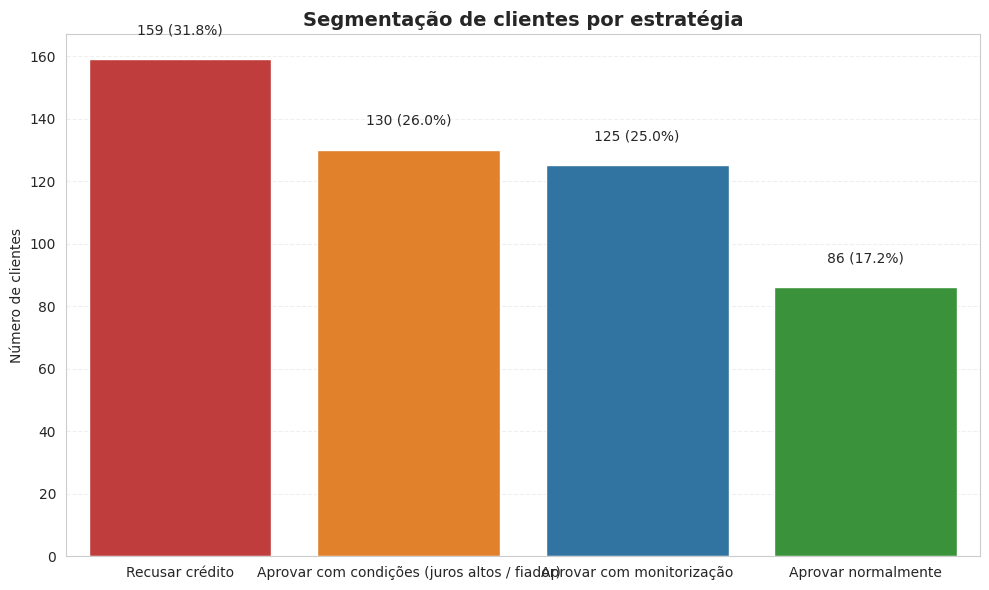

In [37]:
# Contagem e ordenação por nível de risco
ordem = [
    "Recusar crédito",
    "Aprovar com condições (juros altos / fiador)",
    "Aprovar com monitorização",
    "Aprovar normalmente"
]

# Criar cópia apenas para melhorar os rótulos do gráfico
df_plot = df_scored.copy()

df_plot["Recomendacao_plot"] = df_plot["Recomendacao"].replace({
    "Recusar crédito": "Recusar crédito",
    "Aprovar com condições (juros altos / fiador)": "Aprovar com condições (juros altos / fiador)",
    "Aprovar com monitorização": "Aprovar com monitorização",
    "Aprovar normalmente": "Aprovar normalmente"
})

counts = df_plot["Recomendacao_plot"].value_counts().reindex(ordem)

# Percentagens
percent = counts / counts.sum() * 100

# Cores por criticidade
cores = ["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=cores
)

plt.title("Segmentação de clientes por estratégia", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Número de clientes")

# Valores e percentagens
for i, (val, pct) in enumerate(zip(counts.values, percent)):
    ax.text(i, val + 8, f"{val} ({pct:.1f}%)", ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Clientes prioritários

In [43]:
# Age  Income  LoanAmount  LoanTerm  CreditScore  LatePayments  DebtToIncome EmploymentType Region  Outcome

clientes_prioritarios=df_scored.sort_values(
"Outcome",
ascending=False
)[[
"ClientID",
"Region",
"EmploymentType",
"Age",
"Income",
"LoanAmount",
"LoanTerm",
"CreditScore",
"Outcome",
"LatePayments",
"DebtToIncome",
"Recomendacao"
]].head(20)

print("CLIENTES PRIORITÁRIOS")
print(clientes_prioritarios.to_string(index=False))


CLIENTES PRIORITÁRIOS
ClientID Region EmploymentType  Age  Income  LoanAmount  LoanTerm  CreditScore  Outcome  LatePayments  DebtToIncome    Recomendacao
 C100379  North      Full-time   43    2770       11883        24          365 0.974129             9          0.88 Recusar crédito
 C100205 Center      Full-time   64    4623       12213        24          329 0.958985             9          0.90 Recusar crédito
 C100255  North      Full-time   21    1513        5929        24          337 0.949119             8          0.40 Recusar crédito
 C100422  South  Self-employed   36    3065       19940        12          403 0.947543             8          0.82 Recusar crédito
 C100039  South  Self-employed   29    3738        1322        12          400 0.947216             8          0.83 Recusar crédito
 C100152  South      Full-time   27    1310        4140        60          459 0.942759             9          0.89 Recusar crédito
 C100251  South      Part-time   27    4145       1601

## 15. Distribuição do risco

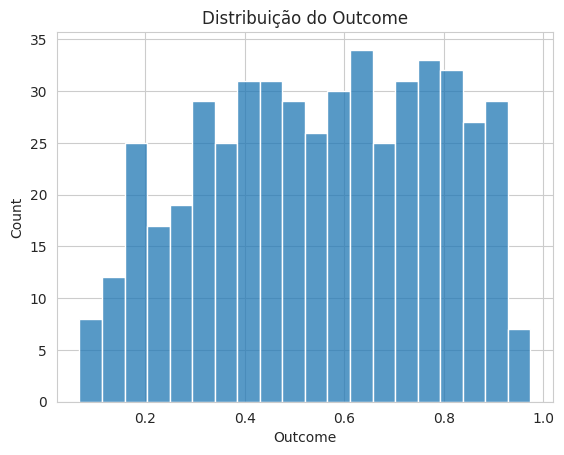

In [44]:
sns.histplot(df_scored["Outcome"],bins=20)
plt.title("Distribuição do Outcome")
plt.show()
